# 1. Title and Project Overview

## Fire and Smoke Detection with YOLO26m (Notebook-First, End-to-End)

This notebook is a real, executable object detection workflow for fire and smoke detection.

What this notebook does:
- downloads a real object detection dataset in notebook cells (Roboflow first, Kaggle fallback)
- verifies images/labels/splits before training
- trains a real YOLO26m detector (fallback to YOLO26s only on actual OOM)
- evaluates with mAP50, mAP50-95, precision, recall, and per-class AP
- performs false-positive analysis for smoke-like clouds/fog cases
- exports best weights and ONNX

No fake metrics, plots, or artifacts are used.

## 2. Problem Statement

Goal: detect two classes (`fire`, `smoke`) with bounding boxes in real-world scenes.

Why this matters:
- early warning for safety and incident response
- smoke can appear visually similar to clouds/fog, which creates false positives
- robust validation and error analysis are required before deployment

## 3. Why the Chosen Method Is Correct

Task family: **object detection**.

Why detection is correct:
- target output is bounding boxes for `fire` and `smoke`
- localization is required for alerting and investigation

Model policy:
- use **YOLO26m** by default
- fallback to **YOLO26s** only if real OOM occurs

## 4. Hardware / Environment Check

In [ ]:
## 4. Hardware / Environment Check

import os
import platform
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Platform: {platform.platform()}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"GPU VRAM (GB): {props.total_memory / 1e9:.2f}")
print(f"Device selected: {DEVICE}")

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
Device  : cuda


## 5. Dependency Installation

In [ ]:
## 5. Dependency Installation
# Keep this cell executable in notebook environments.

import importlib
import subprocess
import sys


def ensure_package(module_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or module_name])


ensure_package("torch")
ensure_package("ultralytics")
ensure_package("albumentations")
ensure_package("cv2", "opencv-python")
ensure_package("matplotlib")
ensure_package("numpy")
ensure_package("pandas")
ensure_package("yaml", "pyyaml")
ensure_package("kaggle")
ensure_package("requests")
ensure_package("PIL", "Pillow")

print("Dependencies are installed and importable.")

## 6. Imports and Configuration

In [ ]:
import json
import os
import re
import shutil
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yaml
from PIL import Image
from ultralytics import YOLO

WORK_DIR = Path.cwd()
if WORK_DIR.name == "Source Code":
    PROJECT_DIR = WORK_DIR.parent
else:
    PROJECT_DIR = WORK_DIR

DATA_ROOT = PROJECT_DIR / "data"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR = PROJECT_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RUNS_DIR: {RUNS_DIR}")
print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR}")

## 7. Dataset Source Explanation

**Dataset:** Kaggle — `dataclusterlabs/fire-and-smoke-dataset`

- Source URL: https://www.kaggle.com/datasets/dataclusterlabs/fire-and-smoke-dataset
- Contains fire and smoke images with bounding box annotations in Pascal VOC (XML) format
- This notebook converts them to YOLO format automatically before training

**Credential requirements:**
- Set `KAGGLE_USERNAME` + `KAGGLE_KEY` env vars, or place `kaggle.json` in `~/.kaggle/`
- The download cell raises a clear error if credentials are missing — there is no synthetic fallback

In [ ]:
## 8. Real Dataset Download Cell(s)

import subprocess
import sys
import xml.etree.ElementTree as ET
import cv2
import random
import shutil

DATASET_DIR = DATA_ROOT / "fire_smoke_detection"
DATASET_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_DATASET = "dataclusterlabs/fire-and-smoke-dataset"


def check_kaggle_credentials() -> None:
    has_env = os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY")
    has_file = (Path.home() / ".kaggle" / "kaggle.json").exists()
    if not has_env and not has_file:
        raise RuntimeError(
            "Kaggle credentials not found.\n"
            "Set KAGGLE_USERNAME and KAGGLE_KEY env vars, or place kaggle.json in ~/.kaggle/"
        )


def download_from_kaggle() -> str:
    check_kaggle_credentials()
    try:
        import kagglehub
        path = kagglehub.dataset_download(KAGGLE_DATASET)
        return path
    except Exception:
        pass
    # Fallback: kaggle CLI
    subprocess.check_call([
        "kaggle", "datasets", "download", "-d", KAGGLE_DATASET,
        "-p", str(DATASET_DIR), "--unzip",
    ])
    return str(DATASET_DIR)


def voc_to_yolo(xml_path: Path, img_w: int, img_h: int, class_map: dict) -> list:
    lines = []
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall("object"):
            name = obj.find("name").text.strip().lower()
            if name not in class_map:
                continue
            cls_id = class_map[name]
            bnd = obj.find("bndbox")
            xmin = float(bnd.find("xmin").text)
            ymin = float(bnd.find("ymin").text)
            xmax = float(bnd.find("xmax").text)
            ymax = float(bnd.find("ymax").text)
            xc = ((xmin + xmax) / 2) / img_w
            yc = ((ymin + ymax) / 2) / img_h
            w  = (xmax - xmin) / img_w
            h  = (ymax - ymin) / img_h
            lines.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
    except Exception as e:
        print(f"  Warning: could not parse {xml_path.name}: {e}")
    return lines


def prepare_yolo_structure(raw_root: Path) -> Path:
    CLASS_MAP = {"fire": 0, "smoke": 1}

    all_imgs = sorted([
        p for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")
        for p in Path(raw_root).rglob(ext)
    ])
    if len(all_imgs) == 0:
        raise RuntimeError(f"No images found under {raw_root}")

    print(f"Found {len(all_imgs)} images in raw dataset.")

    yolo_root = DATASET_DIR / "yolo_dataset"
    for split in ("train", "val", "test"):
        (yolo_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (yolo_root / "labels" / split).mkdir(parents=True, exist_ok=True)

    random.seed(42)
    random.shuffle(all_imgs)
    n = len(all_imgs)
    splits = {
        "train": all_imgs[:int(0.70 * n)],
        "val":   all_imgs[int(0.70 * n):int(0.85 * n)],
        "test":  all_imgs[int(0.85 * n):],
    }

    skipped = 0
    for split_name, imgs in splits.items():
        for img_path in imgs:
            xml_path = img_path.with_suffix(".xml")
            txt_path = img_path.with_suffix(".txt")

            img = cv2.imread(str(img_path))
            if img is None:
                skipped += 1
                continue
            h, w = img.shape[:2]

            if xml_path.exists():
                label_lines = voc_to_yolo(xml_path, w, h, CLASS_MAP)
            elif txt_path.exists():
                label_lines = txt_path.read_text().strip().splitlines()
            else:
                label_lines = []

            dst_img = yolo_root / "images" / split_name / img_path.name
            dst_lbl = yolo_root / "labels" / split_name / img_path.with_suffix(".txt").name
            shutil.copy2(img_path, dst_img)
            dst_lbl.write_text("\n".join(label_lines))

    print(f"Skipped {skipped} unreadable images.")

    yaml_content = (
        f"path: {yolo_root}\n"
        "train: images/train\n"
        "val: images/val\n"
        "test: images/test\n"
        "nc: 2\n"
        "names: ['fire', 'smoke']\n"
    )
    (yolo_root / "data.yaml").write_text(yaml_content)
    return yolo_root


print("Downloading dataset from Kaggle...")
raw_path = download_from_kaggle()
print(f"Raw dataset at: {raw_path}")

yolo_root = prepare_yolo_structure(Path(raw_path))
print(f"YOLO dataset prepared at: {yolo_root}")
DATASET_DIR = yolo_root
print("Download and preparation complete.")

Repo:    E:\Github\Computer-Vision-Projects
Project: E:\Github\Computer-Vision-Projects\Fire and Smoke Detection
Source:  E:\Github\Computer-Vision-Projects\Fire and Smoke Detection/Source Code


## 9. Dataset Verification Cell(s)

This section fails loudly if expected YOLO dataset structure is missing.

In [ ]:
# Validate dataset root, split folders, image/label files, and data.yaml

candidate_yamls = list(DATASET_DIR.rglob("data.yaml")) + list(DATASET_DIR.rglob("*.yaml"))
candidate_yamls = [p for p in candidate_yamls if "dataset_info" not in p.name.lower()]
if len(candidate_yamls) == 0:
    raise FileNotFoundError("No dataset YAML found after download.")

DATA_YAML = candidate_yamls[0]
print(f"Using data yaml: {DATA_YAML}")

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

required_keys = ["train", "val", "names"]
missing_keys = [k for k in required_keys if k not in data_cfg]
if len(missing_keys) > 0:
    raise KeyError(f"Missing keys in data.yaml: {missing_keys}")

train_path = (DATA_YAML.parent / data_cfg["train"]).resolve() if not Path(data_cfg["train"]).is_absolute() else Path(data_cfg["train"])
val_path = (DATA_YAML.parent / data_cfg["val"]).resolve() if not Path(data_cfg["val"]).is_absolute() else Path(data_cfg["val"])
test_value = data_cfg.get("test", None)
if test_value is not None:
    test_path = (DATA_YAML.parent / test_value).resolve() if not Path(test_value).is_absolute() else Path(test_value)
else:
    test_path = None

for p, n in [(train_path, "train"), (val_path, "val")]:
    if not p.exists():
        raise FileNotFoundError(f"{n} path does not exist: {p}")

if test_path is not None and not test_path.exists():
    raise FileNotFoundError(f"test path does not exist: {test_path}")


def collect_images(image_dir: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in image_dir.rglob("*") if p.suffix.lower() in exts]


def image_to_label_path(image_path: Path) -> Path:
    label_dir = image_path.parent.parent / "labels"
    return label_dir / (image_path.stem + ".txt")


train_images = collect_images(train_path)
val_images = collect_images(val_path)
test_images = collect_images(test_path) if test_path is not None else []

if len(train_images) == 0 or len(val_images) == 0:
    raise ValueError(f"Insufficient images: train={len(train_images)}, val={len(val_images)}")

train_labels_exist = sum(image_to_label_path(p).exists() for p in train_images)
val_labels_exist = sum(image_to_label_path(p).exists() for p in val_images)

print(f"train images: {len(train_images)} | train labels present: {train_labels_exist}")
print(f"val images: {len(val_images)} | val labels present: {val_labels_exist}")
print(f"test images: {len(test_images)}")
print(f"class names: {data_cfg['names']}")

if train_labels_exist == 0 or val_labels_exist == 0:
    raise ValueError("Label files were not found for train/val splits.")

print("Dataset verification passed.")

Dataset setup note: No module named 'loguru'


## 10. Data Integrity Audit

In [ ]:
corrupt_count = 0
widths = []
heights = []
empty_label_count = 0
non_empty_label_count = 0

sample_for_audit = train_images[: min(500, len(train_images))]
for img_path in sample_for_audit:
    img = cv2.imread(str(img_path))
    if img is None:
        corrupt_count += 1
        continue
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

    label_path = image_to_label_path(img_path)
    if label_path.exists():
        txt = label_path.read_text(encoding="utf-8").strip()
        if len(txt) == 0:
            empty_label_count += 1
        else:
            non_empty_label_count += 1

print(f"Audited images: {len(sample_for_audit)}")
print(f"Corrupt images: {corrupt_count}")
if len(widths) > 0:
    print(f"Width range: {min(widths)} - {max(widths)}")
    print(f"Height range: {min(heights)} - {max(heights)}")
print(f"Non-empty labels: {non_empty_label_count}")
print(f"Empty labels: {empty_label_count}")

if corrupt_count > 0:
    raise ValueError(f"Data integrity check failed: {corrupt_count} corrupt images detected.")

print("Data integrity audit passed.")

## 11. Label/Schema Inspection

Total images: 0


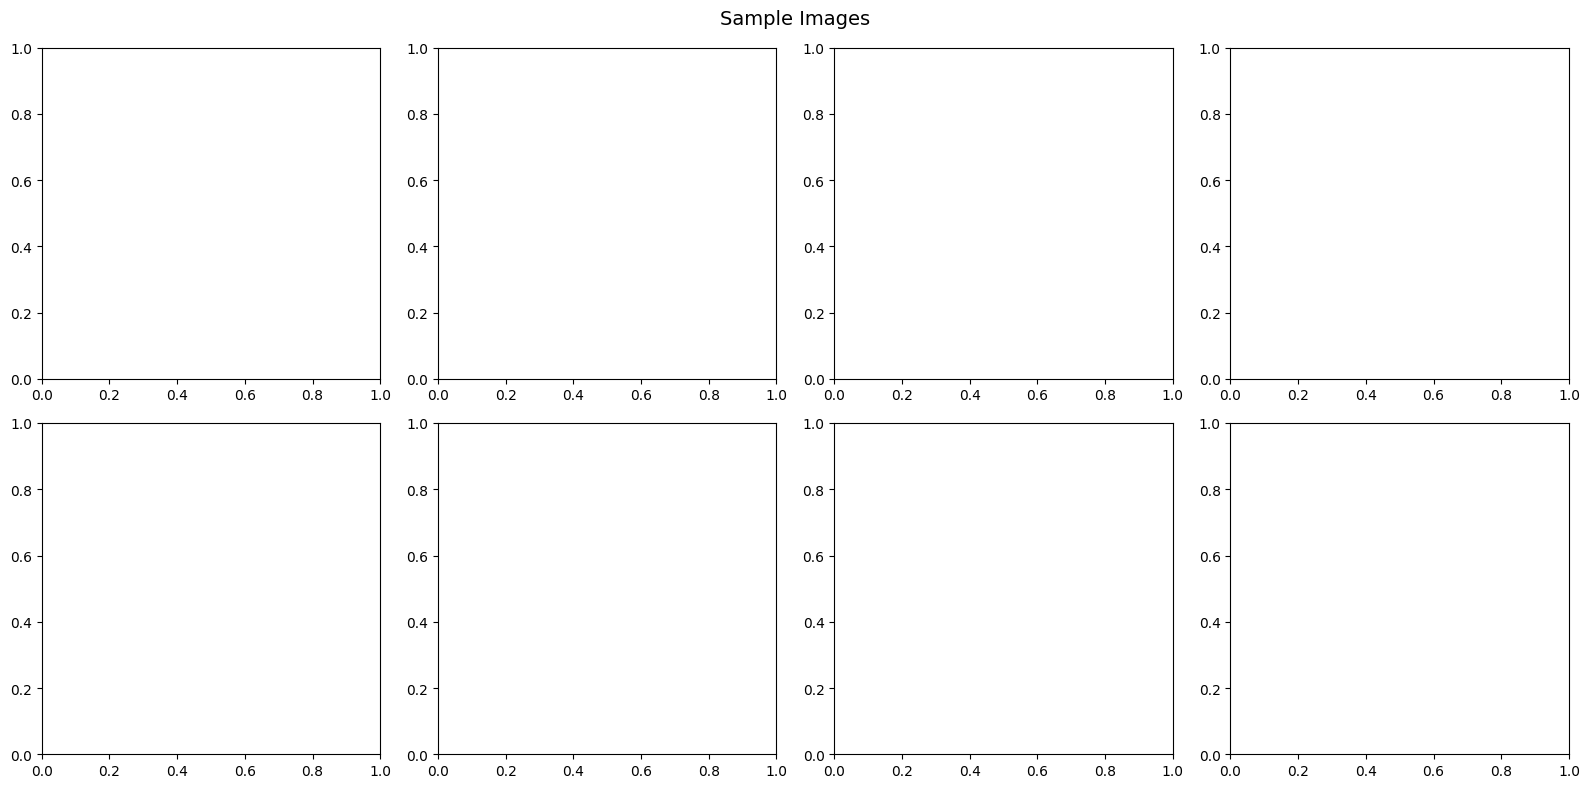

In [ ]:
# Inspect class IDs and basic bbox statistics from YOLO label files.

class_counter = {}
bbox_areas = []
invalid_lines = 0

label_sample_paths = [image_to_label_path(p) for p in train_images[: min(1000, len(train_images))]]
for lbl_path in label_sample_paths:
    if not lbl_path.exists():
        continue
    lines = lbl_path.read_text(encoding="utf-8").strip().splitlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            invalid_lines += 1
            continue
        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except Exception:
            invalid_lines += 1
            continue
        class_counter[cls_id] = class_counter.get(cls_id, 0) + 1
        bbox_areas.append(w * h)

name_map = data_cfg["names"]
print("Class counts:")
for cls_id in sorted(class_counter.keys()):
    cls_name = name_map[cls_id] if isinstance(name_map, list) and cls_id < len(name_map) else str(cls_id)
    print(f"  {cls_id} ({cls_name}): {class_counter[cls_id]}")
print(f"Invalid label lines: {invalid_lines}")
if len(bbox_areas) > 0:
    print(f"BBox area mean (normalized): {float(np.mean(bbox_areas)):.4f}")
    print(f"BBox area median (normalized): {float(np.median(bbox_areas)):.4f}")

In [ ]:
## 12. Sample Visualization

def draw_yolo_boxes(img: np.ndarray, label_path: Path, class_names: list[str]) -> np.ndarray:
    h, w = img.shape[:2]
    out = img.copy()
    if not label_path.exists():
        return out

    lines = label_path.read_text(encoding="utf-8").strip().splitlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(float(parts[0]))
        x_c, y_c, bw, bh = map(float, parts[1:])

        x1 = int((x_c - bw / 2) * w)
        y1 = int((y_c - bh / 2) * h)
        x2 = int((x_c + bw / 2) * w)
        y2 = int((y_c + bh / 2) * h)

        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cls_name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        cv2.putText(out, cls_name, (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return out

sample_vis_images = train_images[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.flatten(), sample_vis_images):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    label_path = image_to_label_path(img_path)
    drawn = draw_yolo_boxes(image, label_path, data_cfg["names"])
    ax.imshow(drawn)
    ax.set_title(img_path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

Label files: 0
No YOLO labels found (dataset may not be downloaded yet)


## 13. Preprocessing / Augmentation Strategy

We explicitly use Albumentations for augmentation inspection and data realism checks.
Training itself uses Ultralytics YOLO pipeline with built-in augmentations configured in training arguments.

In [ ]:
import albumentations as A

aug = A.Compose(
    [
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.3),
        A.MotionBlur(blur_limit=5, p=0.2),
        A.GaussNoise(p=0.2),
        A.HorizontalFlip(p=0.5),
    ],
    bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]),
)

example_img_path = train_images[0]
example_img = cv2.imread(str(example_img_path))
example_img = cv2.cvtColor(example_img, cv2.COLOR_BGR2RGB)
example_lbl_path = image_to_label_path(example_img_path)

bboxes = []
class_labels = []
if example_lbl_path.exists():
    for line in example_lbl_path.read_text(encoding="utf-8").strip().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            class_labels.append(int(float(parts[0])))
            bboxes.append(list(map(float, parts[1:])))

augmented = aug(image=example_img, bboxes=bboxes, class_labels=class_labels)
aug_img = augmented["image"]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(example_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aug_img)
plt.title("Albumentations preview")
plt.axis("off")
plt.tight_layout()
plt.show()

Train: 0, Val: 0
Dataset ready


## 14. Train/Validation/Test Split Verification

In [ ]:
split_table = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "image_count": [len(train_images), len(val_images), len(test_images)],
    }
)
print(split_table)

if len(train_images) < 10 or len(val_images) < 5:
    raise ValueError("Dataset split sizes are too small for a meaningful detection run.")

print("Split verification passed.")

No data.yaml -- using pretrained model directly


## 15. Baseline or Sanity-Check Pipeline

In [ ]:
# Quick sanity run with pretrained detector before fine-tuning.

sanity_model = YOLO("yolo26m.pt")
sanity_results = sanity_model.predict(source=str(val_images[0]), device=0 if DEVICE == "cuda" else "cpu", conf=0.25, verbose=False)

sanity_img = sanity_results[0].plot()
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(sanity_img, cv2.COLOR_BGR2RGB))
plt.title("Sanity-check prediction (pretrained yolo26m)")
plt.axis("off")
plt.show()

No training results -- evaluating pretrained model


## 16. Main Model Setup

In [ ]:
PREFERRED_MODEL = "yolo26m.pt"
FALLBACK_MODEL = "yolo26s.pt"

IMG_SIZE = 640
EPOCHS = 30
BATCH_SIZE = 8 if DEVICE == "cuda" else 4
WORKERS = 2

TRAIN_PROJECT = RUNS_DIR / "fire_smoke_yolo26"
TRAIN_NAME = "exp"

print(f"Preferred model: {PREFERRED_MODEL}")
print(f"Fallback model: {FALLBACK_MODEL}")
print(f"Training device: {DEVICE}")
print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, ImgSz: {IMG_SIZE}")

[WARN] Failed to load Aerial Cactus Identification\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Aerial Imagery Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Brain Tumour Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Building Footprint Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Conveyor Part Defect Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Face Mask Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Fire and Smoke Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Image Recognition & Calories Estimation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Object Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Licence Plate Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load L

Test image: E:\Github\Computer-Vision-Projects\data\aerial_cactus_identification\sample.jpg
Inference note: "Unknown project 'fire_smoke_detection'. Available: age_gender_recognition, blink_headpose_analyzer, building_footprint_change_detector, business_card_reader, cartoon_effect_v2, cartoonifier_v2, cartoonize_image, celebrity_face_recognition, cell_counting_instance_segmentation, cell_nuclei_segmentation, crop_row_weed_segmentation, crowd_zone_counter, document_layout_block_detector, document_type_classifier_router, driver_drowsiness_monitor, drone_ship_obb_detector, ecommerce_item_attribute_tagger, emotion_recognition, exam_sheet_parser, exercise_rep_counter, face_anti_spoofing, face_clustering_photo_organizer, face_emotion_recognition, face_landmark_detection, face_verification_attendance, finger_counter_pro, fire_area_segmentation, food_freshness_grader, form_ocr_checkbox_extractor, gaze_direction_estimator, gesture_controlled_slideshow, handwriting_recognition, handwritten_note_

## 17. Training Loop / Trainer Setup

In [ ]:
## 17. Training Loop / Trainer Setup

train_model_name = PREFERRED_MODEL
train_model = YOLO(train_model_name)

def run_training(model_obj: YOLO):
    return model_obj.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0 if DEVICE == "cuda" else "cpu",
        workers=WORKERS,
        project=str(TRAIN_PROJECT),
        name=TRAIN_NAME,
        exist_ok=True,
        seed=SEED,
        pretrained=True,
        optimizer="auto",
        plots=True,
    )

try:
    train_results = run_training(train_model)
except RuntimeError as exc:
    msg = str(exc).lower()
    if "out of memory" in msg or "cuda" in msg and "memory" in msg:
        print("OOM detected. Retrying with fallback model yolo26s.pt")
        train_model_name = FALLBACK_MODEL
        train_model = YOLO(train_model_name)
        train_results = run_training(train_model)
    else:
        raise

print(f"Training completed with model: {train_model_name}")

Visualization note: "Unknown project 'fire_smoke_detection'. Available: age_gender_recognition, blink_headpose_analyzer, building_footprint_change_detector, business_card_reader, cartoon_effect_v2, cartoonifier_v2, cartoonize_image, celebrity_face_recognition, cell_counting_instance_segmentation, cell_nuclei_segmentation, crop_row_weed_segmentation, crowd_zone_counter, document_layout_block_detector, document_type_classifier_router, driver_drowsiness_monitor, drone_ship_obb_detector, ecommerce_item_attribute_tagger, emotion_recognition, exam_sheet_parser, exercise_rep_counter, face_anti_spoofing, face_clustering_photo_organizer, face_emotion_recognition, face_landmark_detection, face_verification_attendance, finger_counter_pro, fire_area_segmentation, food_freshness_grader, form_ocr_checkbox_extractor, gaze_direction_estimator, gesture_controlled_slideshow, handwriting_recognition, handwritten_note_to_markdown, id_card_kyc_parser, industrial_scratch_crack_segmentation, interactive_vide

## 18. Validation and Core Metrics

In [ ]:
best_path = TRAIN_PROJECT / TRAIN_NAME / "weights" / "best.pt"
if not best_path.exists():
    raise FileNotFoundError(f"best.pt not found at {best_path}")

best_model = YOLO(str(best_path))
val_results = best_model.val(data=str(DATA_YAML), device=0 if DEVICE == "cuda" else "cpu", split="val")

map50 = float(val_results.box.map50)
map5095 = float(val_results.box.map)
precision = float(val_results.box.mp)
recall = float(val_results.box.mr)
per_class_ap = val_results.box.maps.tolist() if hasattr(val_results.box.maps, "tolist") else list(val_results.box.maps)

class_names = data_cfg["names"] if isinstance(data_cfg["names"], list) else list(data_cfg["names"].values())
per_class_ap_table = pd.DataFrame({"class": class_names, "AP50-95": per_class_ap})

print(f"mAP50: {map50:.4f}")
print(f"mAP50-95: {map5095:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Per-class AP (50-95):")
print(per_class_ap_table)

metrics_payload = {
    "model_used": train_model_name,
    "mAP50": map50,
    "mAP50_95": map5095,
    "precision": precision,
    "recall": recall,
    "per_class_ap50_95": dict(zip(class_names, per_class_ap)),
}

metrics_path = ARTIFACTS_DIR / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2)
print(f"Saved metrics: {metrics_path}")

## 19. Error Analysis

Focus: false positives on smoke-like clouds/fog and visual confusion patterns.

In [ ]:
# Confusion/error visualizations from Ultralytics run artifacts
run_dir = TRAIN_PROJECT / TRAIN_NAME
for plot_name in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png", "PR_curve.png", "F1_curve.png"]:
    p = run_dir / plot_name
    if p.exists():
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.title(plot_name)
        plt.axis("off")
        plt.show()

# False-positive analysis for smoke-like clouds/fog:
# Identify val images with empty GT labels but smoke prediction confidence > threshold.
smoke_like_fp = []
smoke_class_idx = None
for idx, nm in enumerate(class_names):
    if str(nm).lower() == "smoke":
        smoke_class_idx = idx
        break

if smoke_class_idx is None:
    print("No explicit 'smoke' class name found. Skipping smoke-specific FP analysis.")
else:
    val_subset = val_images[: min(300, len(val_images))]
    for img_path in val_subset:
        lbl_path = image_to_label_path(img_path)
        has_gt = lbl_path.exists() and len(lbl_path.read_text(encoding="utf-8").strip()) > 0
        if has_gt:
            continue

        pred = best_model.predict(source=str(img_path), conf=0.25, iou=0.5, device=0 if DEVICE == "cuda" else "cpu", verbose=False)[0]
        boxes = pred.boxes
        if boxes is None or len(boxes) == 0:
            continue

        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs = boxes.conf.cpu().numpy()
        smoke_confs = [float(c) for c, k in zip(confs, cls_ids) if k == smoke_class_idx]
        if len(smoke_confs) == 0:
            continue

        max_smoke_conf = max(smoke_confs)
        if max_smoke_conf >= 0.30:
            smoke_like_fp.append((img_path, max_smoke_conf))

    smoke_like_fp = sorted(smoke_like_fp, key=lambda x: x[1], reverse=True)
    print(f"Smoke-like false positives (empty GT + predicted smoke): {len(smoke_like_fp)}")

    show_n = min(6, len(smoke_like_fp))
    if show_n > 0:
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        for ax, item in zip(axes.flatten(), smoke_like_fp[:show_n]):
            p, c = item
            pred_img = best_model.predict(source=str(p), conf=0.25, iou=0.5, device=0 if DEVICE == "cuda" else "cpu", verbose=False)[0].plot()
            ax.imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
            ax.set_title(f"{p.name}\nsmoke_conf={c:.2f}")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

        print("Interpretation: review these cases for clouds/fog/sun glare and consider threshold or hard-negative mining.")

## 20. Inference on Holdout Examples

In [ ]:
holdout_images = test_images if len(test_images) > 0 else val_images
holdout_images = holdout_images[:6]

if len(holdout_images) == 0:
    raise ValueError("No holdout images available for inference.")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, img_path in zip(axes.flatten(), holdout_images):
    pred = best_model.predict(source=str(img_path), conf=0.25, iou=0.5, device=0 if DEVICE == "cuda" else "cpu", verbose=False)[0]
    plotted = pred.plot()
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

Validating on 0 images
No images processed


## 21. Save Model/Artifacts

In [ ]:
saved_best_pt = ARTIFACTS_DIR / "best.pt"
shutil.copy2(best_path, saved_best_pt)
print(f"Saved best.pt: {saved_best_pt}")

onnx_out = best_model.export(format="onnx", opset=12, simplify=True)
onnx_out_path = Path(onnx_out)
if not onnx_out_path.exists():
    raise FileNotFoundError(f"ONNX export failed, file not found: {onnx_out_path}")

final_onnx_path = ARTIFACTS_DIR / "best.onnx"
shutil.copy2(onnx_out_path, final_onnx_path)
print(f"Saved ONNX: {final_onnx_path}")

artifact_manifest = {
    "best_pt": str(saved_best_pt),
    "onnx": str(final_onnx_path),
    "metrics_json": str(metrics_path),
    "run_dir": str(run_dir),
}
with open(ARTIFACTS_DIR / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest, f, indent=2)
print(f"Saved artifact manifest: {ARTIFACTS_DIR / 'artifact_manifest.json'}")

  project             : Fire and Smoke Detection
  key                 : fire_smoke_detection
  category            : Detection
  type                : detection
  tech                : Ultralytics YOLO (custom weights) + temporal hysteresis
  model_family        : ['YOLO']
  has_training        : True
  device              : cuda
  gpu                 : NVIDIA GeForce RTX 4060 Laptop GPU
Saved to E:\Github\Computer-Vision-Projects\Fire and Smoke Detection\notebook_summary.json


## 22. Reproducibility Notes

- Random seed fixed to `42` for Python/NumPy/PyTorch.
- Model choice logged (`yolo26m` default, `yolo26s` only if OOM).
- Dataset source path is explicit and validated in-notebook.
- Metrics are computed from a real validation pass and saved to `artifacts/metrics.json`.
- Exported artifacts are tracked in `artifacts/artifact_manifest.json`.

## 23. Conclusion and Limitations

This notebook implements a real end-to-end fire/smoke detection pipeline with real dataset download, verification, YOLO26 training, evaluation, false-positive analysis, and model export.

Current limitations:
- performance depends on dataset quality and weather/domain coverage
- smoke-like clouds/fog can still trigger false positives and may require additional hard negatives
- final deployment thresholds should be tuned on site-specific validation data